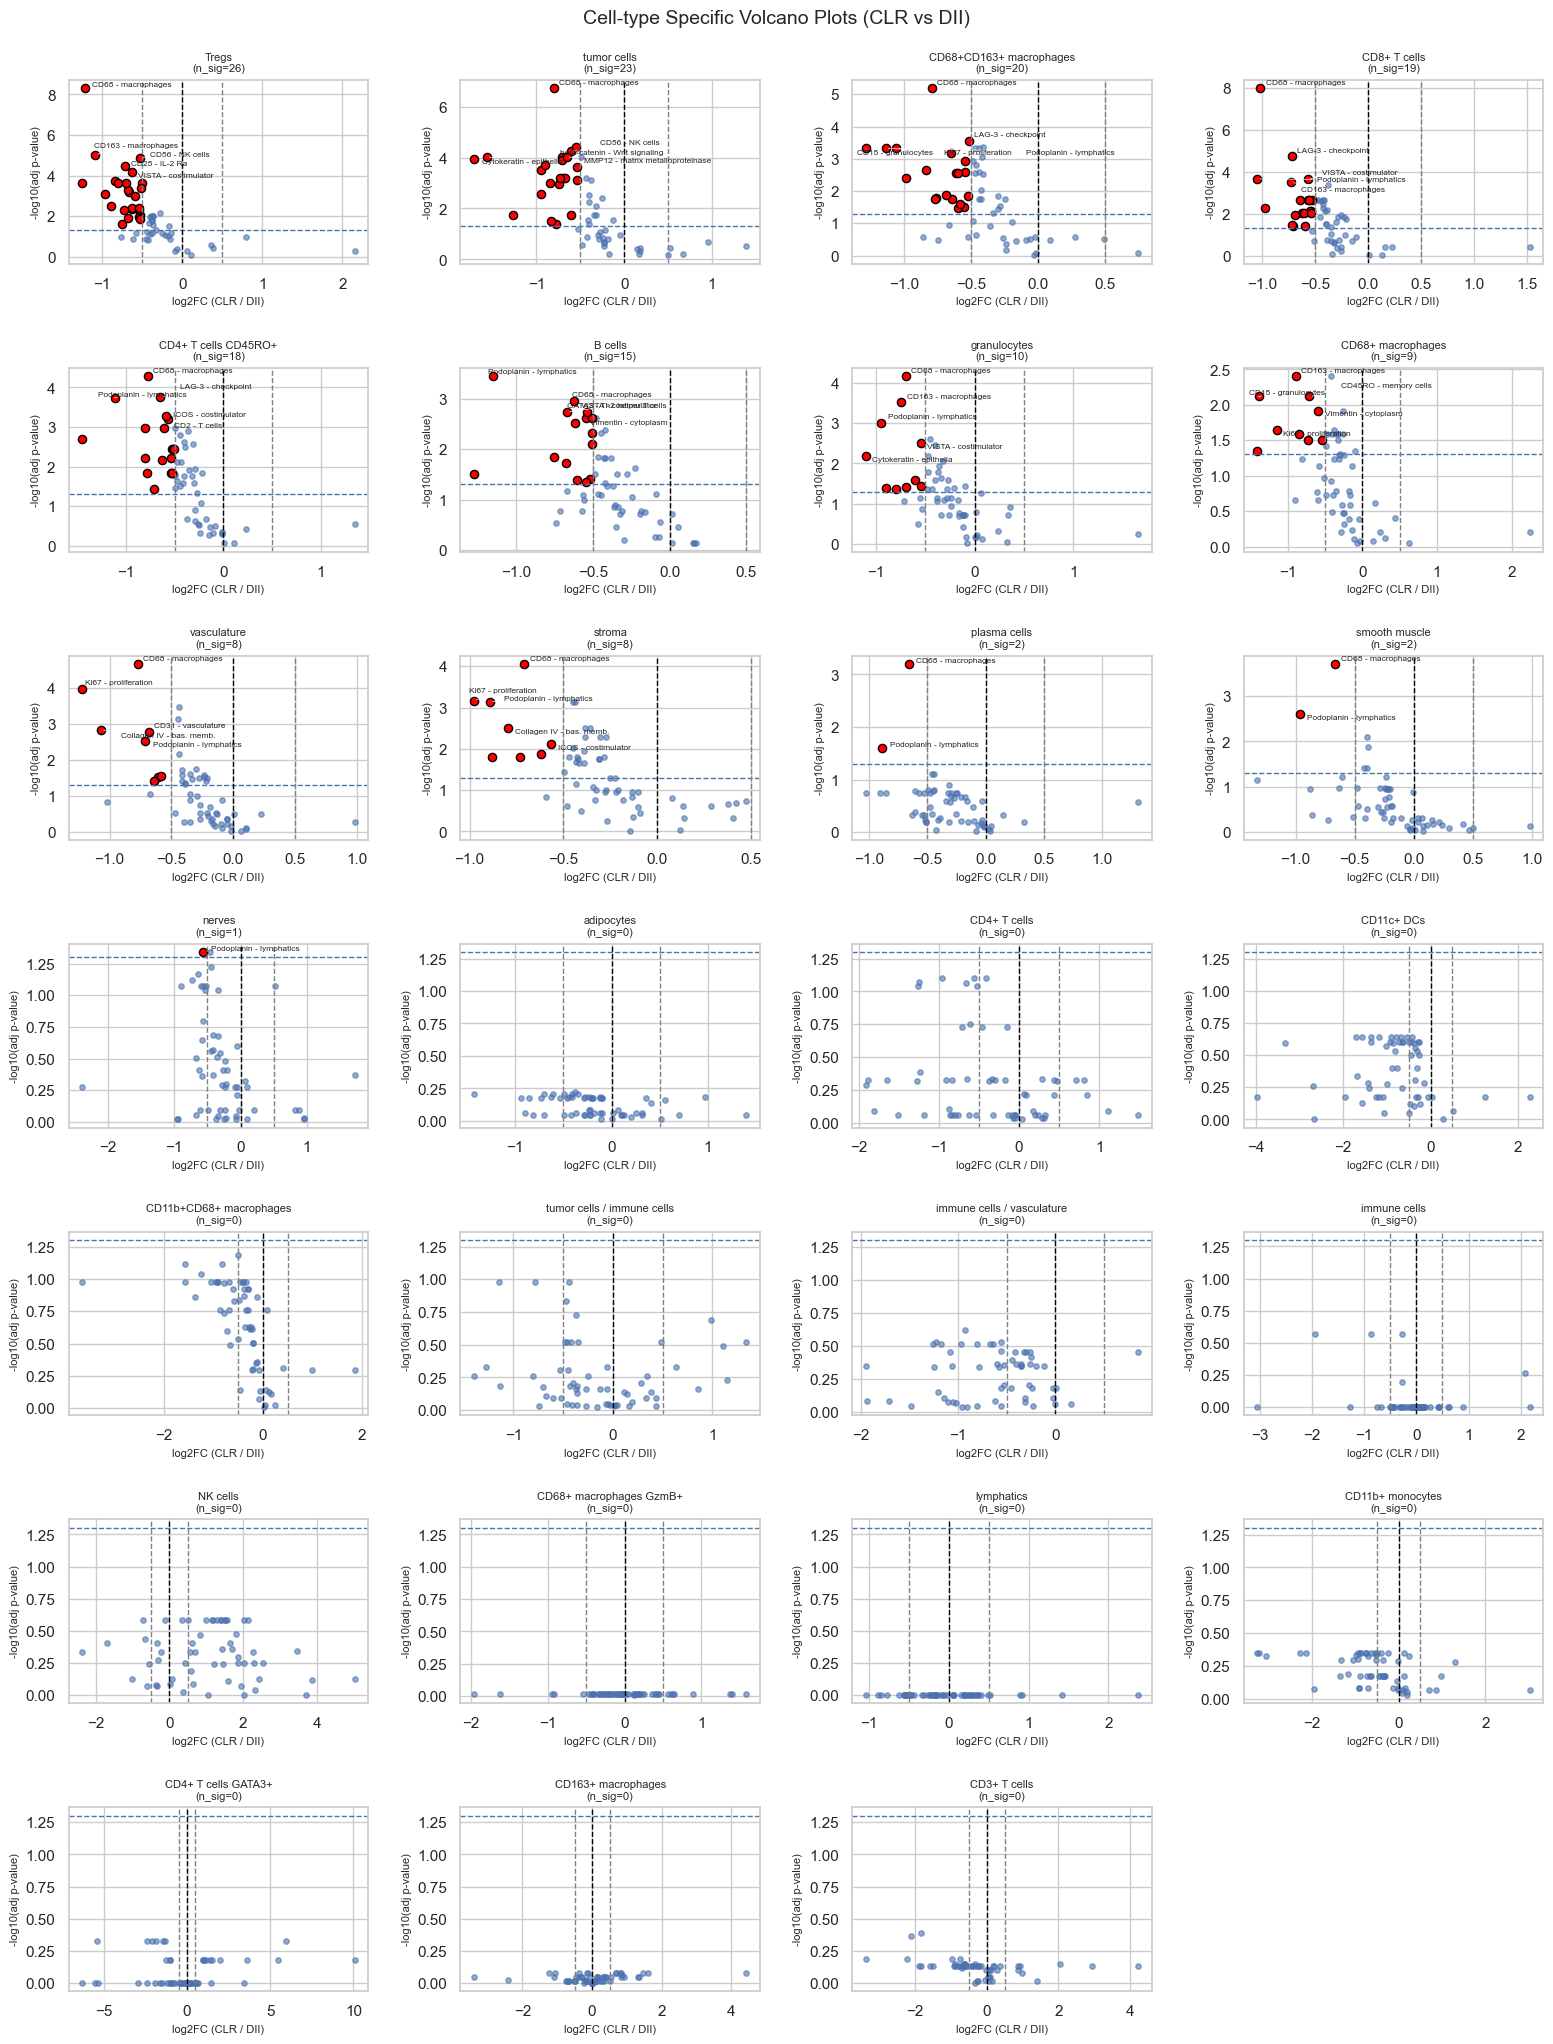

In [2]:
import pandas as pd
import numpy as np
import re
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

sns.set(style="whitegrid")

# ==============================
# PARAMETERS
# ==============================
OUTPUT_FILE = "celltype_marker_results.xlsx"

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("CRC_clusters_neighborhoods_markers.csv")
df["group_label"] = df["groups"].map({1: "CLR", 2: "DII"})
df = df[~df['ClusterName'].isin(['dirt', 'undefined'])]

# ==============================
# MARKERS
# ==============================
marker_cols = [
    col for col in df.columns
    if ("Cyc_" in col) and ("ch_" in col)
]

marker_name_map = {col: col.split(":")[0] for col in marker_cols}

# ==============================
# GET CELL TYPES
# ==============================
cell_types = df["ClusterName"].dropna().unique()

# ==============================
# CLEAN EXCEL SHEET NAME
# ==============================
def clean_sheet_name(name):
    name = re.sub(r'[\[\]\:\*\?\/\\]', '_', str(name))
    return name[:31]

# ==============================
# STEP 1: RANK CELL TYPES
# ==============================
cell_type_rank = []

for cell_type in cell_types:

    sub_df = df[df["ClusterName"] == cell_type].copy()

    if sub_df["group_label"].nunique() < 2:
        continue

    slide_df = sub_df.groupby("spots")[marker_cols].mean().reset_index()
    groups = sub_df.groupby("spots")["group_label"].first().reset_index()
    slide_df = slide_df.merge(groups, on="spots")

    if slide_df["group_label"].value_counts().min() < 3:
        continue

    temp_results = []

    for marker in marker_cols:
        clr_vals = slide_df[slide_df["group_label"] == "CLR"][marker]
        dii_vals = slide_df[slide_df["group_label"] == "DII"][marker]

        if len(clr_vals) < 3 or len(dii_vals) < 3:
            continue

        _, p = mannwhitneyu(clr_vals, dii_vals)
        logFC = np.log2((clr_vals.mean() + 1e-6) / (dii_vals.mean() + 1e-6))

        temp_results.append((p, logFC))

    if len(temp_results) == 0:
        continue

    p_vals = [x[0] for x in temp_results]
    logFCs = [x[1] for x in temp_results]

    adj_p_vals = multipletests(p_vals, method="fdr_bh")[1]

    num_sig = np.sum((adj_p_vals < 0.05) & (np.abs(logFCs) > 0.5))

    cell_type_rank.append((cell_type, num_sig))

# ==============================
# SORT CELL TYPES
# ==============================
sorted_cell_types = [
    ct for ct, _ in sorted(cell_type_rank, key=lambda x: x[1], reverse=True)
]

# ==============================
# SETUP FIGURE GRID
# ==============================
n = len(sorted_cell_types)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = axes.flatten()

# ==============================
# EXCEL WRITER
# ==============================
writer = pd.ExcelWriter("Supplementary_Table_S5_Cell_Type_Specific_Protein_Marker.xlsx", engine="xlsxwriter")

# ==============================
# LOOP THROUGH CELL TYPES
# ==============================
all_sig_results = []

for i, cell_type in enumerate(sorted_cell_types):

    ax = axes[i]

    sub_df = df[df["ClusterName"] == cell_type].copy()

    if sub_df["group_label"].nunique() < 2:
        ax.axis("off")
        continue

    slide_df = sub_df.groupby("spots")[marker_cols].mean().reset_index()
    groups = sub_df.groupby("spots")["group_label"].first().reset_index()
    slide_df = slide_df.merge(groups, on="spots")

    if slide_df["group_label"].value_counts().min() < 3:
        ax.axis("off")
        continue

    # ==============================
    # STATS
    # ==============================
    results = []

    for marker in marker_cols:
        clr_vals = slide_df[slide_df["group_label"] == "CLR"][marker]
        dii_vals = slide_df[slide_df["group_label"] == "DII"][marker]

        if len(clr_vals) < 3 or len(dii_vals) < 3:
            continue

        _, p = mannwhitneyu(clr_vals, dii_vals, alternative="two-sided")

        results.append({
            "marker": marker_name_map[marker],
            "logFC": np.log2((clr_vals.mean() + 1e-6) / (dii_vals.mean() + 1e-6)),
            "p_value": p
        })

    if len(results) == 0:
        ax.axis("off")
        continue

    res_df = pd.DataFrame(results)

    # ==============================
    # FDR
    # ==============================
    res_df["adj_p_value"] = multipletests(res_df["p_value"], method="fdr_bh")[1]
    res_df["neg_log10_adj_p"] = -np.log10(res_df["adj_p_value"] + 1e-10)

    res_df["cell_type"] = cell_type

    # ==============================
    # SIGNIFICANCE
    # ==============================
    sig = (res_df["adj_p_value"] < 0.05) & (res_df["logFC"].abs() > 0.5)

    sig_df = res_df[sig].copy()
    all_sig_results.append(sig_df)

    # ==============================
    # SAVE PER CELL TYPE
    # ==============================
    sheet_name = clean_sheet_name(cell_type)
    res_df.sort_values("adj_p_value").to_excel(writer, sheet_name=sheet_name, index=False)

    # ==============================
    # PLOT
    # ==============================
    ax.scatter(res_df["logFC"], res_df["neg_log10_adj_p"], alpha=0.6, s=15)

    ax.scatter(
        res_df[sig]["logFC"],
        res_df[sig]["neg_log10_adj_p"],
        color="red",
        s=35,
        edgecolor="black"
    )

    # ==============================
    # LABEL TOP MARKERS (NEW)
    # ==============================
    texts = []

    top_markers = res_df[sig].sort_values("adj_p_value").head(5)

    for _, row in top_markers.iterrows():
        texts.append(
            ax.text(
                row["logFC"],
                row["neg_log10_adj_p"],
                row["marker"],
                fontsize=6
            )
        )

    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5))

    # ==============================
    # THRESHOLDS
    # ==============================
    ax.axhline(-np.log10(0.05), linestyle="--", linewidth=1)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(0.5, linestyle="--", color="grey", linewidth=1)
    ax.axvline(-0.5, linestyle="--", color="grey", linewidth=1)

    ax.set_title(f"{cell_type}\n(n_sig={sig.sum()})", fontsize=8)

    ax.set_ylabel("-log10(adj p-value)", fontsize=8)
    ax.set_xlabel("log2FC (CLR / DII)", fontsize=8)


# ==============================
# CLEAN EMPTY PLOTS
# ==============================
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# ==============================
# COMBINED SIGNIFICANT MARKERS
# ==============================
if len(all_sig_results) > 0:
    combined_df = pd.concat(all_sig_results, ignore_index=True)
    combined_df = combined_df.sort_values("adj_p_value")

    combined_df.to_excel(
        writer,
        sheet_name="Differential_Markers",
        index=False
    )

writer.close()

# ==============================
# FINAL PLOT
# ==============================
plt.suptitle("Cell-type Specific Volcano Plots (CLR vs DII)", fontsize=14)
plt.tight_layout(pad=2.0)

plt.savefig("Volcano_Cell_Type_Specific_Protein_Marker.png", dpi=600)

plt.show()